In [58]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("housing.csv")

In [37]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

### Drop (Remove) null-value datas

In [38]:
# drop 207 null-value rows
df = df.dropna()

In [39]:
# rechecking
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   ocean_proximity     20433 non-null  str    
 9   median_house_value  20433 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB


### Label encoding (ocean_proximity)

In [41]:
df["ocean_proximity"].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [42]:
df["ocean_proximity"] = df["ocean_proximity"].map({
    "NEAR BAY":0,
    "<1H OCEAN":1,
    "INLAND":2, 
    "NEAR OCEAN":3, 
    "ISLAND":4
})


In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  int64  
 3   total_rooms         20433 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  int64  
 6   households          20433 non-null  int64  
 7   median_income       20433 non-null  float64
 8   ocean_proximity     20433 non-null  int64  
 9   median_house_value  20433 non-null  int64  
dtypes: float64(4), int64(6)
memory usage: 1.7 MB


## features and target

In [45]:
X = df.drop("median_house_value", axis=1) # select only features (col 0 to 8)
y = df["median_house_value"]

print(X)
print(y)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                  41          880           129.0   
1        -122.22     37.86                  21         7099          1106.0   
2        -122.24     37.85                  52         1467           190.0   
3        -122.25     37.85                  52         1274           235.0   
4        -122.25     37.85                  52         1627           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                  25         1665           374.0   
20636    -121.21     39.49                  18          697           150.0   
20637    -121.22     39.43                  17         2254           485.0   
20638    -121.32     39.43                  18         1860           409.0   
20639    -121.24     39.37                  16         2785           616.0   

       population  households  median_income  ocean

### scale features
- to standardize the range of independent variables or features

In [47]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
X_scale = scaler.fit_transform(X)

### Train_Test split

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train, X_test, y_train, y_test= train_test_split(X_scale,y,test_size=0.2)

### Train the model

In [59]:
from  sklearn.linear_model import LinearRegression

In [60]:
model = LinearRegression()

In [62]:
model.fit(X_train,y_train) # model training

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Model Evaluation 

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [69]:
y_predict = model.predict(X_test)

# .fit(X_train, y_train) for training model
# .predict(X_test) for testing model

In [71]:
# use testing data
mse = mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
r2 = r2_score(y_test,y_predict)

In [73]:
print(f"Model evaluation")
print(f"MSE: {mse}\nMAE: {mae}\nR2: {r2}")

Model evaluation
MSE: 4621091284.895289
MAE: 50131.358082406674
R2: 0.6488405316763008


### Visualization 

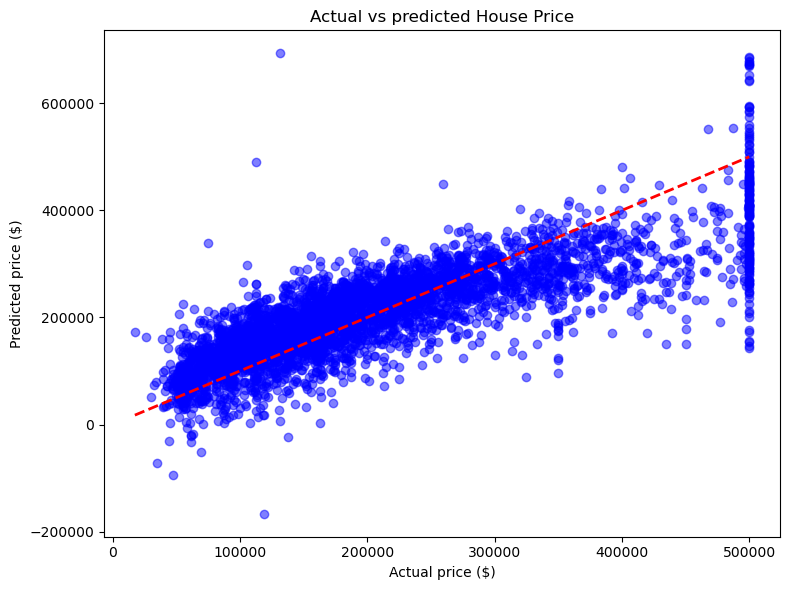

In [80]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_predict, color='b', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--', lw=2)
# r-- = red color dotted line, lw = line width
plt.xlabel("Actual price ($)")
plt.ylabel("Predicted price ($)")
plt.title("Actual vs predicted House Price")

plt.tight_layout()
plt.show()